# Determining Relationship Between Non-Zero Elements and OT Loss
From the previous experiment, it seemed that datasets that were more sparse showed higher OT loss than denser OT datasets. Thus, we will calculate the number of non-zero elements for each file and visualize these relationships.

## Imports

In [48]:
# Enabling fast reload
%load_ext autoreload
%autoreload 2

# Importing
import sys
import re
from pathlib import Path
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
sys.path.append('/Users/oliviersmeets/Desktop/University/Master Internship 1/Data Handling/Scripts')
from hicdatautils import import_cool_dir, fetch_region, get_cool_name, hic_mask_threshold

# Setting data directory
sc_dir = '/Users/oliviersmeets/Desktop/University/Master Internship 1/Data Handling/Data/sc_data'
save_dir = '/Users/oliviersmeets/Desktop/University/Master Internship 1/Data Handling/Generated Data/Single-to-single/sc_cell_type_clustering/ot'

# Saving metadata
metadata = pd.read_csv(sc_dir+"/cell_types.tsv", sep='\t')
metadata_save_dir = '/Users/oliviersmeets/Desktop/University/Master Internship 1/Data Handling/Generated Data/Single-to-single/sc_cell_type_clustering/metadata' 

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Helper Functions

In [47]:
def map_cell_types(data: pd.DataFrame):
    '''
        Transforms fille name to file name comparisons in a pandas dataframe
        to a long format where each comparison has its own row, specifying inter
        or intra cell type of interest interactions.

        This function assusming formatting used in this notebook.

        Parameters
        ----------
        data : pd.DataFrame
            File name to file name dataframe of comparisons (SCC or OT).

        Returns
        -------
        data_long : pd.DataFrame
            A long format version of data with cell type information.
    '''

    # Mapping file to type
    type_lookup = metadata.set_index("cell_name")["cell_type"]

    # Long format
    data_long = data.reset_index().rename(columns={"index": "row_file"})
    data_long = data_long.melt(id_vars="row_file",
                        var_name="col_file",
                        value_name="value")
    # Mapping celltypes
    data_long["row_cell_type"] = data_long["row_file"].map(type_lookup)
    data_long["col_cell_type"] = data_long["col_file"].map(type_lookup)

    # Inter and intra
    data_long["relationship"] = (
        data_long["row_cell_type"] == data_long["col_cell_type"]
        ).map({True: "intra", False: "inter"})

    return data_long

def load_ot_results_long(folder: str, res: int, thres: int, cell_count: int):
    '''
        Loads all csv files corresponding to OT results
        in the given folder.

        This function is very specific to this notebook.

        Parameters
        ----------
        folder : str
            Path to folder that is to be imported.
        res : int
            Resolution used for analysis.
        thres : int
            Threshold used for analysis.
        cell_count : int
            Number of cells used for analysis.
        
        Returns
        -------
        ot_df_long : pd.Dataframe
            Long form dataframe with combined data from all
            OT results.
    '''
    folder = Path(folder)
    
    # Storage dictonary
    ot_dfs = []

    # Regex patterns
    cc = re.escape(str(cell_count))

    pattern = re.compile(
        rf"^(.*?)_type_clustering_ot_{res}mb_{thres}_{cell_count}\.csv$"
    )

    for file in folder.glob("*.csv"):
        name = file.name

        m = pattern.match(name)
        if m:
            df = pd.read_csv(file, index_col=0)
            ot_dfs.append(df)

    # Covert to long and concatenate
    metadata = pd.read_csv(sc_dir+"/cell_types.tsv", sep='\t')
    ot_dfs_long = []
    for df in ot_dfs:
        ot_dfs_long.append(map_cell_types(df))
    
    ot_df_long = pd.concat(ot_dfs_long)

    return ot_df_long

def log10_formatter(y, pos):
    return r"$10^{%d}$" % y

## Calculating Non-Zero Elements

In [6]:
### Importing data ###
    # Import cools
sc_cools = import_cool_dir(sc_dir)

    # Extract chr1 and name
sc_chr1s = []
sc_names = []
for clr in sc_cools:
    sc_chr1s.append(fetch_region(clr, 'chr1'))
    sc_names.append(get_cool_name(clr))
del sc_cools

In [11]:
### Calculating Non-Zero Elements ###
sc_nonzero_lengths = []

for chr1 in sc_chr1s:
    sc_nonzero_lengths.append(len(hic_mask_threshold(chr1, 90, "percentile", "sum")[0]))

In [20]:
### Making Dataframe ###
sc_lengths = pd.DataFrame({
    'file_name': sc_names,
    'nonzero_values': sc_nonzero_lengths
})

sc_lengths.to_csv(f'{metadata_save_dir}/sc_nonzero_lengths_1mb_90.csv')

## Adding Metadata to Long Dataframe

In [22]:
### Loading Data ###
long_1mb_90 = load_ot_results_long(save_dir, 1, 90, 20)
long_1mb_90

,row_file,col_file,value,row_cell_type,col_cell_type,relationship
0,arc_pair_221519,arc_pair_221519,0.000000,CD4+ T cells,CD4+ T cells,intra
1,arc_pair_206257,arc_pair_221519,413.689424,CD4+ T cells,CD4+ T cells,intra
2,arc_pair_25587,arc_pair_221519,3491.812746,CD4+ T cells,CD4+ T cells,intra
3,arc_pair_682126,arc_pair_221519,1777.843349,CD4+ T cells,CD4+ T cells,intra
4,arc_pair_610128,arc_pair_221519,2824.323372,CD4+ T cells,CD4+ T cells,intra
...,...,...,...,...,...,...
3055,arc_pair_119264,arc_pair_723396,1348.757761,CD8+ T cells,Neutrophils,inter
3056,arc_pair_625567,arc_pair_723396,659.691342,CD8+ T cells,Neutrophils,inter
3057,arc_pair_24655,arc_pair_723396,772.329712,CD8+ T cells,Neutrophils,inter
3058,arc_pair_649523,arc_pair_723396,3930.392909,CD8+ T cells,Neutrophils,inter


In [41]:
### Mapping file counts ###
count_map = sc_lengths.set_index('file_name')['nonzero_values']

    # Mapping counts to main df
long_1mb_90['row_count'] = long_1mb_90['row_file'].map(count_map)
long_1mb_90['col_count'] = long_1mb_90['col_file'].map(count_map)

    # Other count values
long_1mb_90['count_sum'] = long_1mb_90["row_count"] + long_1mb_90['col_count']
long_1mb_90['count_avg'] = long_1mb_90['count_sum'] / 2
long_1mb_90['count_diff'] = abs(long_1mb_90['row_count'] - long_1mb_90['col_count'])
long_1mb_90['log_value'] = np.log10(long_1mb_90['value'])
long_1mb_90

/opt/anaconda3/envs/hicotenv/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


,row_file,col_file,value,row_cell_type,col_cell_type,relationship,row_count,col_count,count_sum,count_avg,count_diff,log_value
0,arc_pair_221519,arc_pair_221519,0.000000,CD4+ T cells,CD4+ T cells,intra,278,278,556,278.0,0,-inf
1,arc_pair_206257,arc_pair_221519,413.689424,CD4+ T cells,CD4+ T cells,intra,294,278,572,286.0,16,2.616674
2,arc_pair_25587,arc_pair_221519,3491.812746,CD4+ T cells,CD4+ T cells,intra,312,278,590,295.0,34,3.543051
3,arc_pair_682126,arc_pair_221519,1777.843349,CD4+ T cells,CD4+ T cells,intra,788,278,1066,533.0,510,3.249893
4,arc_pair_610128,arc_pair_221519,2824.323372,CD4+ T cells,CD4+ T cells,intra,280,278,558,279.0,2,3.450914
...,...,...,...,...,...,...,...,...,...,...,...,...
3055,arc_pair_119264,arc_pair_723396,1348.757761,CD8+ T cells,Neutrophils,inter,350,481,831,415.5,131,3.129934
3056,arc_pair_625567,arc_pair_723396,659.691342,CD8+ T cells,Neutrophils,inter,545,481,1026,513.0,64,2.819341
3057,arc_pair_24655,arc_pair_723396,772.329712,CD8+ T cells,Neutrophils,inter,345,481,826,413.0,136,2.887803
3058,arc_pair_649523,arc_pair_723396,3930.392909,CD8+ T cells,Neutrophils,inter,547,481,1028,514.0,66,3.594436


## Making Graphs

Text(0.5, 0.98, 'Non-Zero Element Counts to OT Loss (1 Mb, 90th percentile removed)')

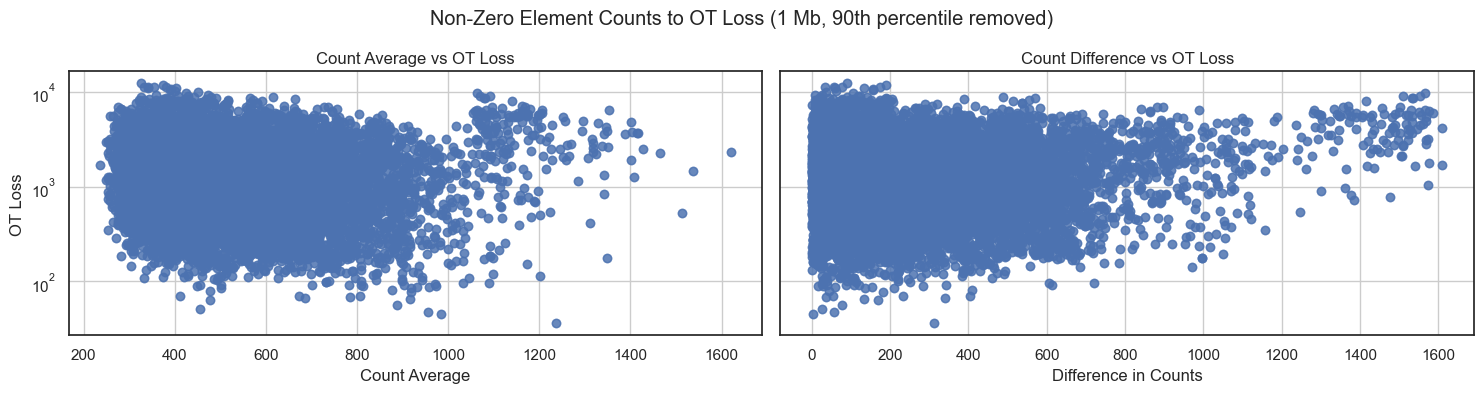

In [43]:
### Making an overview figure ###
long_1mb_90_nonzero = long_1mb_90[long_1mb_90['value']!=0]

fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(15, 4),
    sharey=True
)

x_cols = ['count_avg', 'count_diff']
x_titles = ['Count Average', 'Difference in Counts']
titles = ['Count Average vs OT Loss', 'Count Difference vs OT Loss']

for ax, x_col, title, x_title in zip(axes, x_cols, titles, x_titles):
    ax.scatter(long_1mb_90_nonzero[x_col], long_1mb_90_nonzero['value'], alpha=0.6)
    ax.set_xlabel(x_title)
    ax.set_title(title)
    ax.set_yscale('log')
    ax.grid(True)

axes[0].set_ylabel('OT Loss')

plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.suptitle("Non-Zero Element Counts to OT Loss (1 Mb, 90th percentile removed)")

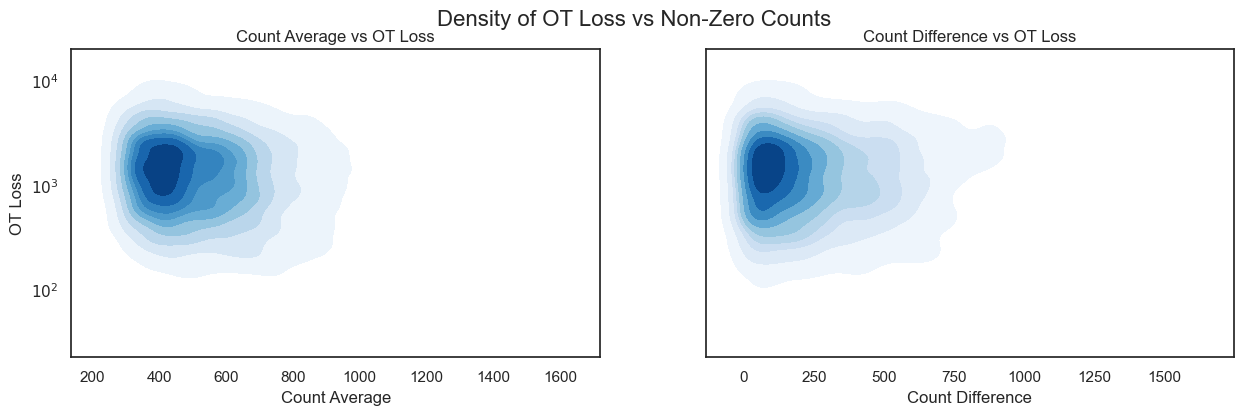

In [51]:
### Contour Plots ###
sns.set_theme(style="white")

fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(15, 4),
    sharey=True
)

plots = [
    ('count_avg', 'Count Average vs OT Loss', 'Count Average'),
    ('count_diff', 'Count Difference vs OT Loss', 'Count Difference'),
]

for ax, (x_col, title, x_title) in zip(axes, plots):
    sns.kdeplot(
        data=long_1mb_90_nonzero,
        x=x_col,
        y='log_value',
        ax=ax,
        fill=True,       
        cmap="Blues"       
    )
    ax.set_title(title)
    ax.set_xlabel(x_title)

    # Handle proper y-axis scale
    ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(log10_formatter))

axes[0].set_ylabel('OT Loss')

fig.suptitle("Density of OT Loss vs Non-Zero Counts", fontsize=16)
plt.show()

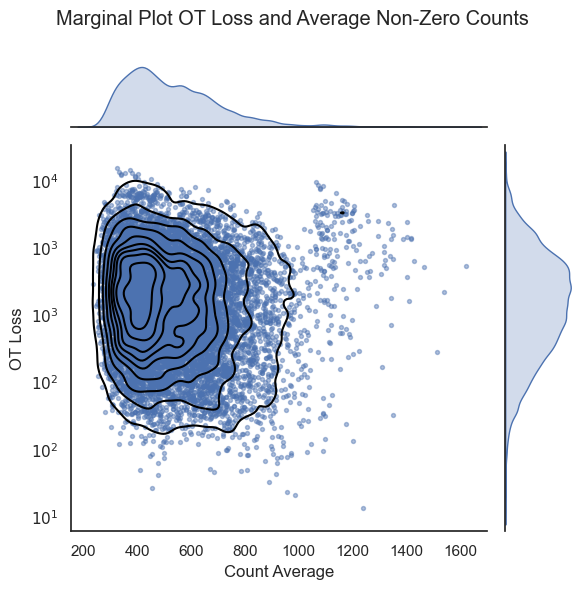

In [ ]:
### Marginal Plot, Averages ###
sns.set_theme(style="white")

g = sns.JointGrid(
    data=long_1mb_90_nonzero,
    x='count_avg',
    y='log_value',
    height=6
)

# Joint: light scatter + contour KDE
g.ax_joint.scatter(
    long_1mb_90_nonzero['count_avg'],
    long_1mb_90_nonzero['log_value'],
    s=8,
    alpha=0.25
)

sns.kdeplot(
    data=long_1mb_90_nonzero,
    x='count_avg',
    y='log_value',
    ax=g.ax_joint,
    levels=10,
    bw_adjust=0.8,
    color='black'
)

# Marginals
sns.kdeplot(
    data=long_1mb_90_nonzero,
    x='count_avg',
    ax=g.ax_marg_x,
    fill=True,
    bw_adjust=0.8
)

sns.kdeplot(
    data=long_1mb_90_nonzero,
    y='log_value',
    ax=g.ax_marg_y,
    fill=True,
    bw_adjust=0.8
)

# Axis labels
g.set_axis_labels('Count Average', 'OT Loss')

# Format y-axis back to 10^y
g.ax_joint.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda y, _: rf"$10^{{{int(y)}}}$")
)

# Title
g.figure.suptitle('Marginal Plot OT Loss and Average Non-Zero Counts')
g.figure.tight_layout(rect=[0, 0, 1, 0.98])

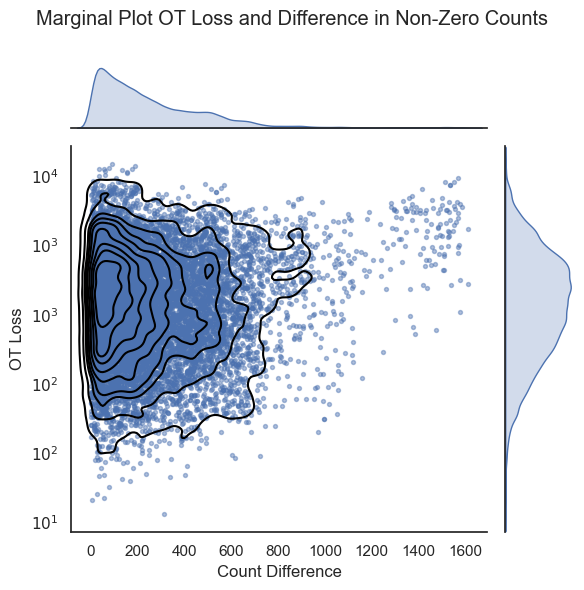

In [61]:
### Marginal Plot, Difference ###
g = sns.JointGrid(
    data=long_1mb_90_nonzero,
    x='count_diff',
    y='log_value',
    height=6
)

# Joint
g.ax_joint.scatter(
    long_1mb_90_nonzero['count_diff'],
    long_1mb_90_nonzero['log_value'],
    s=8,
    alpha=0.25
)

sns.kdeplot(
    data=long_1mb_90_nonzero,
    x='count_diff',
    y='log_value',
    ax=g.ax_joint,
    levels=10,
    bw_adjust=0.6,  
    color='black'
)

# Marginals
sns.kdeplot(
    data=long_1mb_90_nonzero,
    x='count_diff',
    ax=g.ax_marg_x,
    fill=True,
    bw_adjust=0.6
)

sns.kdeplot(
    data=long_1mb_90_nonzero,
    y='log_value',
    ax=g.ax_marg_y,
    fill=True,
    bw_adjust=0.8
)

g.set_axis_labels('Count Difference', 'OT Loss')

# Format y-axis to 10^y
g.ax_joint.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda y, _: rf"$10^{{{int(y)}}}$")
)

# Title
g.figure.suptitle('Marginal Plot OT Loss and Difference in Non-Zero Counts')
g.figure.tight_layout(rect=[0, 0, 1, 0.98])